In [1]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from typing import TypedDict,Annotated, List
from pydantic import Field,BaseModel
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import operator
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode,tools_condition

import serpapi
import os

In [2]:
class TravelState(TypedDict):
    user_input: str = Field(description="Latest user query or message related to travel planning.")
    source: str = Field(description="Departure city or location provided by the user (e.g., Indore, DEL).")
    destination: str = Field(description="Arrival city or destination where the user wants to travel (e.g., Pune, BOM).")
    date_from: str = Field(description="Start date of the trip in YYYY-MM-DD or natural language format.")
    date_to: str = Field(description="End date of the trip in YYYY-MM-DD or natural language format.")
    budget: int = Field(description="Total budget for the trip in INR. Should be normalized (e.g., '10k' → 10000).")
    missing_val: List[str] = Field(default_factory=list, description="List of missing required fields among source, destination, date_from, date_to, and budget.")
    missing_question: str = Field(description="Clarification question generated to ask the user for missing trip details.")
    missing_response: str = Field(description="User's response to the clarification question, used to update missing fields.")
    history: List[str] = Field(description="Conversation history storing previous interactions between user and assistant.")

In [3]:
class ParseSchema(BaseModel):
    source:str
    destination:str
    date_from:str
    date_to:str
    missing_val:list[str]=[]
    budget:int

In [4]:
load_dotenv()
model=ChatGroq(model="llama-3.3-70b-versatile")
check_model=model.with_structured_output(ParseSchema)

In [5]:
search_tool=DuckDuckGoSearchRun()
def flight_tool(source:str,destination:str,date:str):
  """
    Search for available flights between two locations on a given date.

    Args:
        source (str): Departure city or airport code (e.g., "DEL", "Delhi").
        destination (str): Arrival city or airport code (e.g., "BOM", "Mumbai").
        date (str): Travel date in YYYY-MM-DD format.

    Returns:
        dict: A dictionary containing:
            - status (str): "success" or "error"
            - data (list): List of best available flights, where each flight may include:
                - airline name
                - departure time
                - arrival time
                - duration
                - price (in INR)
                - booking link (if available)

    Notes:
        - Uses Google Flights data via SerpAPI.
        - Results depend on API availability and may vary.
        - If no flights are found, returns an empty list in 'data'.
  """
  SERPAPI_KEY=os.getenv("SERPAPI_KEY")
  client = serpapi.Client(api_key=SERPAPI_KEY)
  results = client.search({
    "engine": "google_flights",
    "departure_id": {source},
    "currency": "INR",
    "type": "2",
    "outbound_date": {date},
    "arrival_id": {destination}
  })
  best_flights = results["best_flights"]
  return best_flights
tools=[flight_tool]
tool_node=ToolNode(tools)

In [6]:
model_with_tools=model.bind_tools(tools)

In [7]:
model_with_tools.invoke("which is the shortest time flight to go from indore to pune and its price")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'b2xcf874s', 'function': {'arguments': '{"date":"2024-03-20","destination":"PNQ","source":"IDR"}', 'name': 'flight_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 308, 'total_tokens': 342, 'completion_time': 0.099895307, 'completion_tokens_details': None, 'prompt_time': 0.016555017, 'prompt_tokens_details': None, 'queue_time': 0.161669972, 'total_time': 0.116450324}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dc81f-af67-7193-bcb8-f7993f678150-0', tool_calls=[{'name': 'flight_tool', 'args': {'date': '2024-03-20', 'destination': 'PNQ', 'source': 'IDR'}, 'id': 'b2xcf874s', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 308, 'output_tokens': 34, 'total_tokens': 342})

In [8]:
def user_input(state:TravelState):
    user=input("Enter your travel details:")

    return {"user_input":user,"history":[HumanMessage(user)]}
def parse_input_llm(state:TravelState):
    system_prompt="""You are an information extraction assistant.

Your task is to read the user_input string and extract these fields:
- source: str
- destination: str
- date_from: str
- date_to: str
- budget: int
- missing_val: list[str]

Rules:
1. Extract only information explicitly present in the user input.
2. If a field is not found, set it to "".
3. missing_val must contain the names of all fields that are "".
4. If budget is mentioned with words like "10k", convert it to an integer (10000).
5. If dates are mentioned in natural language, convert them to a clear string format.
6. Return ONLY valid JSON.
7. Do not include any extra text.
8. Assume year as 2026 year if not mentioned.
9. If no missing values just return empty list.

Output format:
{
  "source": "",
  "destination": "",
  "date_from": "",
  "date_to": "",
  "budget": "",
  "missing_val": []
}"""
    res=check_model.invoke([SystemMessage(system_prompt),HumanMessage(state["user_input"])])

    return {"source":res.source,"destination":res.destination,"date_from":res.date_from,"budget":res.budget,"date_to":res.date_to,"missing_val":res.missing_val}


In [9]:
def missing_check_router(state:TravelState):
    if(len(state['missing_val'])>0):
        return "ask_missing"
    return "decision_llm"


def ask_missing(state:TravelState):
    prompt=f"""You are a helpful travel assistant.

Your task is to ask the user for missing information required to plan a trip.

Missing fields will be provided as a list:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Ask ONLY for the missing fields.
2. If multiple fields are missing, combine them into a single natural question.
3. Keep the question short, clear, and conversational.
4. Do NOT mention field names like "date_from" or "date_to" — use natural language.
5. If dates are missing, ask for travel dates together.
6. If budget is missing, ask politely for budget range.
7. Do not ask for fields that are already provided.
8. Return ONLY the question (no JSON, no explanation).

Examples:

Missing: ["source"]
→ "Where will you be traveling from?"

Missing: ["destination"]
→ "Where would you like to go?"

Missing: ["date_from", "date_to"]
→ "When are you planning to travel?"

Missing: ["source", "destination", "budget"]
→ "Where will you be traveling from, where would you like to go, and what's your budget?"

Now generate the question based on:
Missing fields: {state['missing_val']}"""
    res=model.invoke(prompt)

    return {"missing_question":res.content,"history":[AIMessage(res.content)]}


def update_input(state:TravelState):
    question=state["missing_question"]
    user=input(question)
    prompt=f"""
You are a travel assistant that updates and summarizes trip details from conversation history.

You are given:
1. Previously extracted trip data
2. A new user response answering missing questions

Your task:
Merge the new response into the previous data and return a COMPLETE, clean, human-readable summary of the trip.

Fields to track:
- source
- destination
- date_from
- date_to
- budget

Rules:
1. Keep all previously filled values unless the user explicitly changes them.
2. Extract any new information from the latest user response.
3. If the user corrects a value, overwrite the old one.
4. Do not remove valid existing data.
5. Convert budget like "10k" → 10000.
6. Normalize dates into a clear readable format.

Output:
- Return a COMPLETE sentence or paragraph describing the trip.
- Include all available details.
- If something is still missing, clearly mention it.

Example Output:
"Trip from Indore to Pune starting on 25 April 2024 and ending on 28 April 2024 with a budget of ₹10000. Missing details: destination."

Input:
Previous data:
{state['history']}

New user response:
{user}
"""
    res=model.invoke(prompt).content
    
    state["missing_question"]=""
    state["missing_val"]=[]
    state["missing_response"]=""

    return {"user_input":res,"history":[HumanMessage(res)]}

In [10]:
def decision_llm(state:TravelState):
   trip_details = f"""
source: {state.get("source", "")}
destination: {state.get("destination", "")}
date_from: {state.get("date_from", "")}
date_to: {state.get("date_to", "")}
budget: {state.get("budget", "")}
"""
   prompt=f""""You are an intelligent travel planning assistant.

Your job is to analyze the user's request and current trip details, then decide the next action.

You have access to the following tools:
{tools}

Current Trip Details:
{trip_details}

User Query:
{state['user_input']}

Your responsibilities:

1. Check if all required trip details are available:
   - source
   - destination
   - date_from
   - date_to
   - budget


2. If sufficient details are available:
   - Decide which tools are needed:
     - Use flight_tool for transport
     - Use web_search if needed

3. Tool Usage Rules:
   - Call ONLY the necessary tools
   - Do NOT call multiple tools unnecessarily
   - Prefer:
       - flight_tool for long distances

4. If all relevant data has already been gathered:
   - Generate a COMPLETE travel itinerary

5. Itinerary must include:
   - Travel summary (source → destination)
   - Best transport option (fastest or cheapest based on query)
   - Hotel suggestions
   - Weather overview
   - Suggested plan (day-wise optional)
   - Budget alignment


Do NOT:
- Explain your reasoning
- Mention tools explicitly in the final answer
- Output raw JSON unless calling a tool

Be precise, efficient, and user-focused."""
   res=model_with_tools.invoke(prompt)

   if res.tool_calls:
      return res.tool_calls
   else:
      return res.content
   return res


In [11]:
s = TravelState({
    'user_input': "I want to go to Indore from pachore from 15 june 2026 to 22 june 2026 with 8000 budget",
    'source': 'pachore',
    'destination': 'Indore',
    'date_from': '15-06-2026',
    'date_to': '22-06-2026',
    'budget': 8000,
    'missing_val': [],
    'missing_question': "",
    'missing_response': "",
    'history': []
})
decision_llm(s)


[{'name': 'flight_tool',
  'args': {'date': '2026-06-15', 'destination': 'Indore', 'source': 'pachore'},
  'id': 'vjf96xx84',
  'type': 'tool_call'}]

In [12]:

def generate_output(state:TravelState):
    pass    
def check_tools(state:TravelState):
    if(len(state["tools"])==0):
        return "generate_output"
    return "need_tool"
def generate_output(state:TravelState):
    pass

In [13]:
s=TravelState(user_input="I want to go to Indore from pachore on 15 june for 7 days")
parse_input_llm(s)

{'source': 'pachore',
 'destination': 'Indore',
 'date_from': '15-06-2026',
 'budget': 0,
 'date_to': '22-06-2026',
 'missing_val': ['budget']}

In [14]:
s=TravelState(missing_val=["budget,destination,source"])
ask_missing(s)

{'missing_question': "Where will you be traveling from, where would you like to go, and what's your budget?",
 'history': [AIMessage(content="Where will you be traveling from, where would you like to go, and what's your budget?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

In [15]:
state=StateGraph(TravelState)
state.add_node("user_input",user_input)
state.add_node("parse_input_llm",parse_input_llm)
state.add_node("ask_missing",ask_missing)
state.add_node("update_input",update_input)
state.add_node("decision_llm",decision_llm)
state.add_node("tool_node",tool_node)
state.add_node("generate_output",generate_output)


state.add_edge(START,"user_input")
state.add_edge("user_input","parse_input_llm")
state.add_conditional_edges("parse_input_llm",missing_check_router,{"decision_llm":"decision_llm","ask_missing":"ask_missing"})
state.add_edge("tool_node","decision_llm")
state.add_conditional_edges("decision_llm",check_tools,{"need_tool":"tool_node","generate_output":"generate_output"})
state.add_edge("ask_missing","update_input")
state.add_edge("update_input","parse_input_llm")
state.add_edge("generate_output",END)


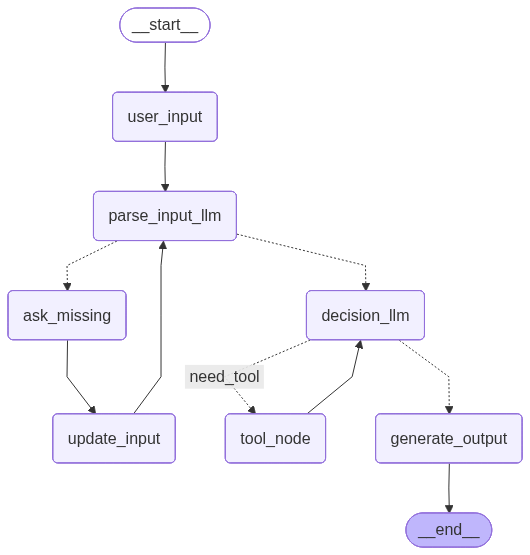

In [16]:
workflow=state.compile()
workflow

In [17]:
workflow.invoke({})

InvalidUpdateError: Expected dict, got [{'name': 'flight_tool', 'args': {'date': '2024-04-25', 'destination': 'Pune', 'source': 'Indore'}, 'id': '2c6pqz3x3', 'type': 'tool_call'}]
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE